## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [52]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/golub.csv')
df['cancer'] = df['cancer'].replace({'allB': 1, 'allT': 1, 'aml': 0})
X = df.iloc[:, 6:]
y = df['cancer']
print(y.unique())

[1 0]


Mean Squared Error: 5.211908817057529e-30


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


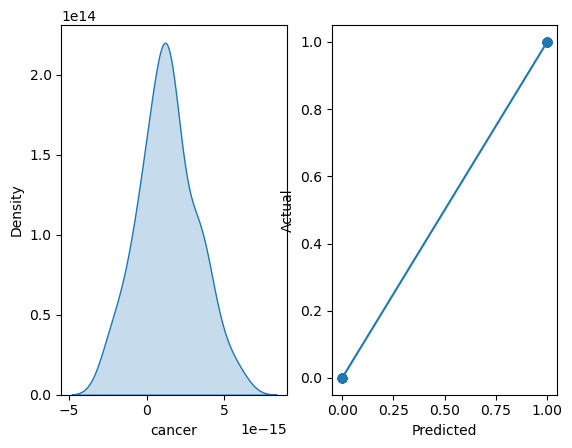

In [53]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")
residuals = y - y_pred

plt.figure()
plt.subplot(1, 2, 1)
sns.kdeplot(residuals, fill=True)
plt.subplot(1, 2, 2)
plt.scatter(y_pred, y)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [54]:
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='neg_mean_squared_error')
cv_mse = -cv_scores.mean()
print(f"MSE: {cv_mse}")
# the trainnig mean squared error is basically 0 because with so many features and relatively few samples, it is basically guaranteed the model is going to overfit, which it did. the cross-validated mse is much higher, which means that there is high variance. bias is low bc linear reg can fit complex relations without resrictions on coefficients, but variance is high because the model is sensitive to the specific training data, thus is bad at generalizing. 

MSE: 0.06013846069061117


Selected: 34
Discarded: 7095


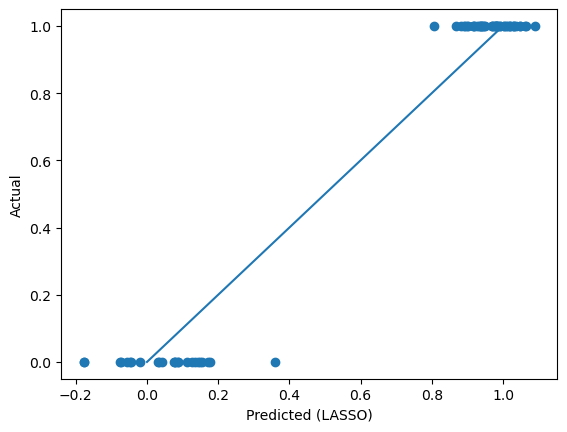

In [55]:
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)
y_pred_lasso = lasso.predict(X)
selected = np.sum(lasso.coef_ != 0)
total = X.shape[1]
discarded = total - selected
print(f"Selected: {selected}")
print(f"Discarded: {discarded}")
plt.figure()
plt.scatter(y_pred_lasso, y)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel('Predicted (LASSO)')
plt.ylabel('Actual')
plt.show()

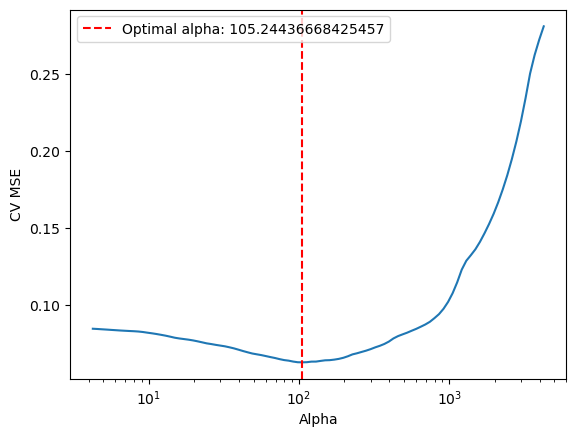

Optimal alpha: 105.24436668425457


In [56]:
alphas = lasso.alphas_
mse_path = lasso.mse_path_.mean(axis=1)  # mean across folds

plt.figure()
plt.plot(alphas, mse_path)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('CV MSE')
plt.axvline(lasso.alpha_, color='r', linestyle='--', label=f'Optimal alpha: {lasso.alpha_}')
plt.legend()
plt.show()

print(f"Optimal alpha: {lasso.alpha_}")

#Underfitting when alpha is large, high bias, and overfitting when alpha is small, high variance.

**Q6**: Linear reg minimizes the training mse without restrictions so with the ratio of features to samples, it creates 0 traning error bc it factors in the noise, and this leads to bad generalization. LASSO adds penality and shrinks the coefficients to zero, leading to better perfomance for unknown data.

**Q7**: Scenarios like precision health have great number of features but small samples, so regularization like LASSO helps pick out the relevant features to help avoid adding in the noise.

**Q8**: LASSO isn't the best when it comes to features that are correlated because it can lead to different seleections of genes even if the datasets are similar. This can lead to false positive/false negatives.